# Tarea 2: Análisis de Imágenes en Python

Esta tarea consiste en analizar imágenes que provienen de un microscopio de barrido electrónico de Escherichia coli. El trabajo consiste en analizar la reducción de la bacteria Escherichia coli (E. coli) tras el tratamiento con nanopartículas de óxido de zinc (ZnO). Las imágenes que se muestran a continuación se obtuvieron con un microscopio electrónico de barrido (MEB), antes y después de 5 horas de tratamiento con ZnO. Un píxel de la imagen tiene un área de 0,02µm².

#### Imagen de SEM antes del tratamiento con ZnO:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/2D-data/bacteria_before.jpg

#### Imagen de SEM después del tratamiento con ZnO:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/2D-data/bacteria_after.jpg

Pueden trabajar individualmente o en grupos de 2 personas.

## Instrucciones:

En base a lo analizado en clase:

https://github.com/wbandabarragan/Bootcamp2025/blob/main/CursoA_Semana1/Clase_02/Clase_2c.ipynb

https://github.com/wbandabarragan/Bootcamp2025/blob/main/CursoA_Semana1/Clase_02/Clase_2d.ipynb

debemos analizar la eficacia de este tratamiento antibacteriano realizando lo siguiente:

- Descargar las dos imágenes anteriores y cargarlas en Google Drive.


In [1]:
import matplotlib.cbook as cbook
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#!ls -alr
#!mkdir /content/drive/MyDrive/Bootcamp2025/homework
%cd /content/drive/MyDrive/Bootcamp2025/homework
#!wget -q https://raw.githubusercontent.com/wbandabarragan/physics-teaching-data/refs/heads/main/2D-data/bacteria_before.jpg
#!wget -q https://raw.githubusercontent.com/wbandabarragan/physics-teaching-data/refs/heads/main/2D-data/bacteria_after.jpg

!ls

/content/drive/MyDrive/Bootcamp2025/homework
bacteria_after.jpg  bacteria_before.jpg



- Graficar las 2 imágenes para revisar el antes y después del tratamiento con ZnO.


In [3]:
bac_after_f = cbook.get_sample_data("/content/drive/MyDrive/Bootcamp2025/homework/bacteria_after.jpg")
bac_before_f = cbook.get_sample_data("/content/drive/MyDrive/Bootcamp2025/homework/bacteria_before.jpg")
#print(type(bac_after_f))
#print(type(bac_before_f))


In [4]:
# New image object:
image_after = plt.imread(bac_after_f)
image_before = plt.imread(bac_before_f)

print(type(image_after), type(image_before))

print(image_after.shape, image_before.shape)

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(346, 563, 3) (346, 563, 3)


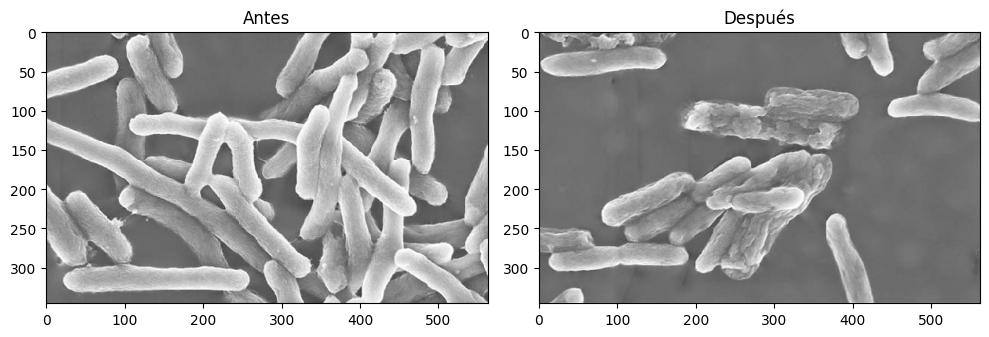

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
# Mostrar la primera imagen
ax[0].imshow(image_before, cmap="magma_r")
ax[0].set_title("Antes")
#ax[0].axis('off')

# Mostrar la segunda imagen
ax[1].imshow(image_after, cmap="magma_r")
ax[1].set_title("Después")
#ax[1].axis('off')

plt.tight_layout()
plt.show()


- Crear histogramas de cada imagen y definir un umbral para remover el fondo.


In [6]:
# we start splitting the channels
bef_imageR = image_before[:, :, 0]
bef_imageG = image_before[:, :, 1]
bef_imageB = image_before[:, :, 2]

af_imageR = image_after[:, :, 0]
af_imageG = image_after[:, :, 1]
af_imageB = image_after[:, :, 2]

print(bef_imageR.shape, bef_imageG.shape, bef_imageB.shape)
print(af_imageR.shape, af_imageG.shape, af_imageB.shape)


(346, 563) (346, 563) (346, 563)
(346, 563) (346, 563) (346, 563)


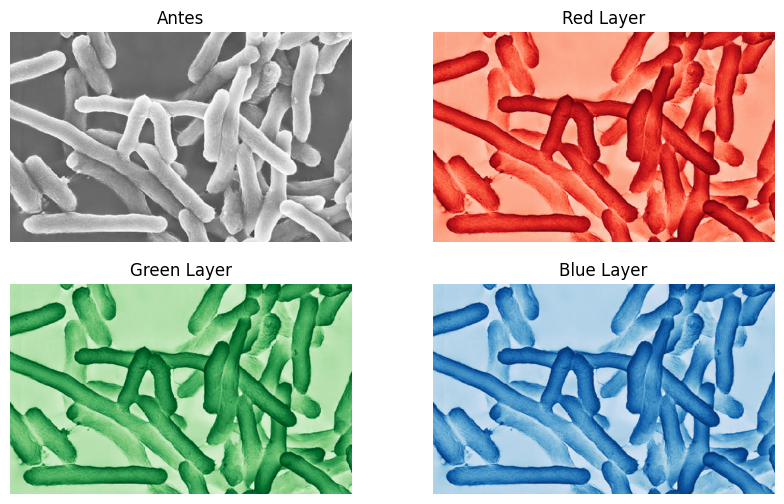

In [7]:
fig, ax = plt.subplots(2,2, figsize=(10,6))

ax[0,0].imshow(image_before, cmap = "magma_r")
ax[0,0].set_title("Antes")
ax[0,0].axis('off')

ax[0,1].imshow(bef_imageR, cmap = "Reds")
ax[0,1].set_title("Red Layer")
ax[0,1].axis('off')

ax[1,0].imshow(bef_imageG, cmap = "Greens")
ax[1,0].set_title("Green Layer")
ax[1,0].axis('off')

ax[1,1].imshow(bef_imageB, cmap = "Blues")
ax[1,1].set_title("Blue Layer")
ax[1,1].axis('off')

plt.show()

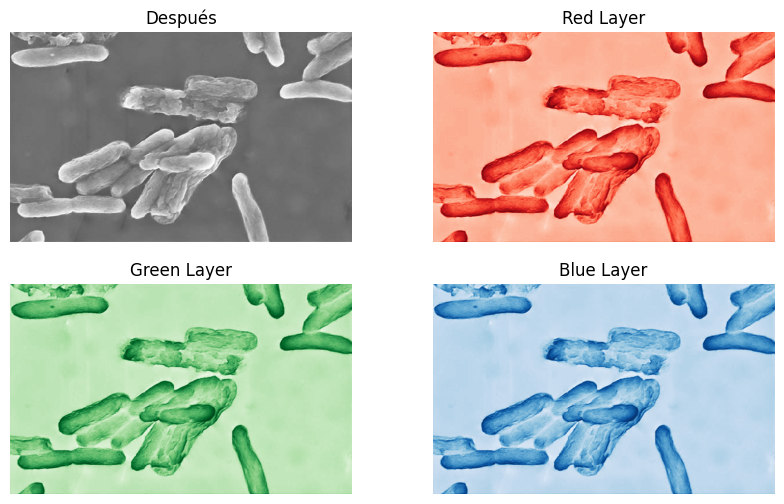

In [8]:
fig, ax = plt.subplots(2,2, figsize=(10,6))

ax[0,0].imshow(image_after, cmap = "magma_r")
ax[0,0].set_title("Después")
ax[0,0].axis('off')

ax[0,1].imshow(af_imageR, cmap = "Reds")
ax[0,1].set_title("Red Layer")
ax[0,1].axis('off')

ax[1,0].imshow(af_imageG, cmap = "Greens")
ax[1,0].set_title("Green Layer")
ax[1,0].axis('off')

ax[1,1].imshow(af_imageB, cmap = "Blues")
ax[1,1].set_title("Blue Layer")
ax[1,1].axis('off')

plt.show()

In [9]:
# Checking the extreme values of each channel
print(np.min(bef_imageR), np.max(bef_imageR))
print(np.min(bef_imageG), np.max(bef_imageG))
print(np.min(bef_imageB), np.max(bef_imageB))

# Checking the extreme values of each channel
print(np.min(af_imageR), np.max(af_imageR))
print(np.min(af_imageG), np.max(af_imageG))
print(np.min(af_imageB), np.max(af_imageB))

39 255
39 255
39 255
54 255
54 255
54 255


In [10]:
# checking the pixel count
print(bef_imageR.size, bef_imageG.size, bef_imageB.size)
print(af_imageR.size, af_imageG.size, af_imageB.size)

194798 194798 194798
194798 194798 194798


In [11]:
# Reshape them into 1D arrays (flatten) It is better to linearise them/reshape into 1D arrays.
bef_imageR_1D = np.reshape(bef_imageR, (bef_imageR.size, 1))
bef_imageB_1D = np.reshape(bef_imageB, (bef_imageB.size, 1))
bef_imageG_1D = np.reshape(bef_imageG, (bef_imageG.size, 1))

af_imageR_1D = np.reshape(af_imageR, (af_imageR.size, 1))
af_imageB_1D = np.reshape(af_imageB, (af_imageB.size, 1))
af_imageG_1D = np.reshape(af_imageG, (af_imageG.size, 1))

print(bef_imageR_1D.shape, bef_imageB_1D.shape, bef_imageG_1D.shape)

(194798, 1) (194798, 1) (194798, 1)


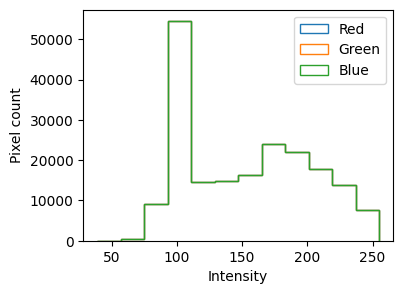

In [12]:
# Plotting histograms
plt.figure(figsize=(4,3))
plt.hist(bef_imageR_1D, bins = 12, histtype='step', label='Red')
plt.hist(bef_imageG_1D, bins = 12, histtype='step', label='Green')
plt.hist(bef_imageB_1D, bins = 12, histtype='step', label='Blue')
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.legend()
plt.show()

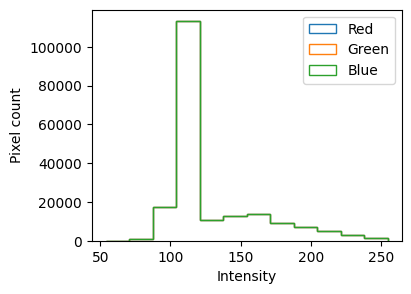

In [13]:
# Plotting some histograms

plt.figure(figsize=(4,3))
plt.hist(af_imageR_1D, bins = 12, histtype='step', label='Red')
plt.hist(af_imageG_1D, bins = 12, histtype='step', label='Green')
plt.hist(af_imageB_1D, bins = 12, histtype='step', label='Blue')
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.legend()
plt.show()

Podemos observar una persistencia en el pico de contador de pixeles en un valor < 130.


- Aplicar un algoritmo de umbral para islar el área cubierta por la bacteria E. coli del fondo. Producir imágenes binarias del antes y después.


In [14]:
print(f"el valor minimo de la imagen antes {np.min(image_before)} y el maximo es {np.max(image_before)}")
print(f"el valor minimo de la imagen despues es {np.min(image_after)} y el maximo es {np.max(image_after)}")

el valor minimo de la imagen antes 39 y el maximo es 255
el valor minimo de la imagen despues es 54 y el maximo es 255


In [15]:
# primero reagurpamos los arreglos en un vector 1D
cell_1d = np.reshape(image_before, (image_before.size, 1))

print(cell_1d.shape)

(584394, 1)


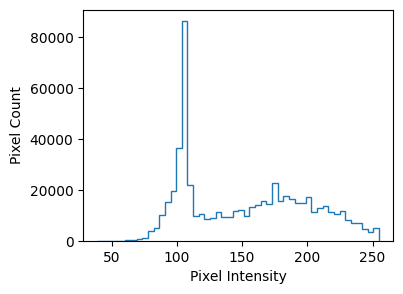

In [16]:
# Histogram plot:

plt.figure(figsize=(4,3))

plt.hist(cell_1d, histtype = "step", bins = 50)


plt.xlabel("Pixel Intensity")
plt.ylabel("Pixel Count")

plt.show()

In [17]:
cell_1d_clean = np.where(cell_1d < 125, np.nan, cell_1d)

In [18]:
# Safe check:
print(cell_1d[0], cell_1d_clean[0])

[104] [nan]


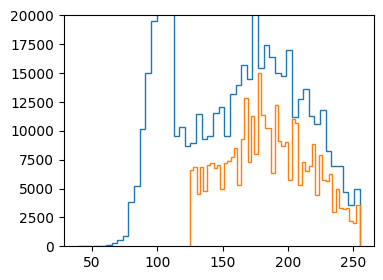

In [19]:
# Check Histogram:

plt.figure(figsize=(4,3))

plt.hist(cell_1d, histtype = "step", bins = 50)
plt.hist(cell_1d_clean, histtype = "step", bins = 50)


plt.ylim(0, 20000)
plt.show()

In [28]:
# Reshape back the result into a 2D array:

cell_image_clean = np.reshape(cell_1d_clean, image_before.shape)

print(image_before.shape, cell_image_clean.shape)

(346, 563, 3) (346, 563, 3)


In [22]:
print("max. value is:", np.nanmax(cell_image_clean))
print("min. value is:", np.nanmin(cell_image_clean))

max. value is: 255.0
min. value is: 125.0


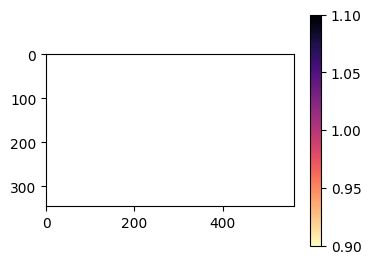

In [29]:
fig, ax = plt.subplots(figsize=(4,3))

Z = ax.imshow(cell_image_clean, cmap = "magma_r")

plt.colorbar(Z)

plt.show()


- Calcular en píxeles y unidades físicas el área total cubierta por la bacteria E. coli antes y después del tratamiento.



- La relación entre dichas áreas: ¿cuán efectivo es el tratamiento antibacteriano con nanopartículas de ZnO?



##### Referencia de imágenes SEM: Zhang et al. 2007, https://link.springer.com/article/10.1007/s11051-006-9150-1

## Preguntas:

Mi nombre es Wladimir Banda Barragán (https://github.com/wbandabarragan)

En caso de inquietudes, pueden escribirme a wbanda@yachaytech.edu.ec

O escribirme por WhatsApp al: 0994745221
